<a href="https://colab.research.google.com/github/tu25002-4828-alt/EU_M_Math-Repository/blob/main/Chap09_Ex_Hw3_1_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#9-2-1調査

###k-means法
k-means法は，各クラスター内のデータ点と，そのクラスターの重心との距離の二乗和である誤差平方和を最小化することを目的としている。具体的には，初期値としてランダムに重心を配置し，各データ点を最も近い重心のクラスターに割り当てる処理と，割り当てられたデータから新しい重心を再計算する処理を，重心が変化しなくなるまで繰り返す。このアルゴリズムの最大の長所は，構造が非常に単純であるため計算量が少なく，大規模なデータセットに対しても極めて高速に動作する点にある。一方で，重心の初期位置を完全にランダムに決定するため，不適切な初期値が選ばれると局所最適解に陥りやすいという初期値依存性の問題がある。さらに，重心を平均値で計算する性質上，外れ値が存在すると重心の座標が大きく引っ張られ，クラスタリング精度が著しく低下してしまう。また，ユークリッド距離に基づく誤差の二乗和を最小化するため，クラスターが球状に分布していることを暗黙の前提としており，複雑な形状のデータには適さないという制約も抱えている。

###k-means++法
k-means++法は，クラスタリングの反復更新プロセス自体は通常のk-means法と完全に同一であるが，初期の重心を選択するアルゴリズムに確率的なアプローチを導入している点が特徴である。具体的には，1つ目の重心をランダムに選んだ後，2つ目以降の重心は「すでに選ばれた重心から遠く離れたデータ点ほど選ばれやすい」という確率的なルールに基づいて決定される。これにより，互いに遠く離れたデータ点が初期重心として選ばれやすくなるため，局所最適解に陥るリスクが大幅に減少し，最適解に対する近似精度が理論的に保証されている。また，不適切な初期値による無駄な反復計算が減るため，結果的に全体の計算時間が短縮されることが多い。初期化ステップにおいて距離の計算と確率分布の更新を順次行うため，初期化部分の計算コストは通常のk-means法よりもやや大きくなるものの，実用上のメリットがその欠点を大きく上回っている。

###k-medoids法
k-medoids法は，データセットの中に実際に存在するデータ点（メドイド）を中心として用いる特徴がある。各データ点と最も近いメドイドとの距離の絶対和を最小化するように更新を繰り返す手法であり，距離関数にはユークリッド距離だけでなくマンハッタン距離などもよく用いられる。平均値ではなく実在の点を中心とし，距離の絶対和を評価するため，外れ値やノイズに対して極めてロバストである点が最大の長所である。また，任意の距離行列を適用できるため，カテゴリ変数などの非連続データにも応用が利く。しかし，アルゴリズムの各反復において，現在のメドイドと非メドイドの全組み合わせを入れ替えた場合のコスト変動を評価するため，計算量が非常に大きくなる。したがって，大規模なデータセットへの適用は現実的ではないという明確な短所をもつ。


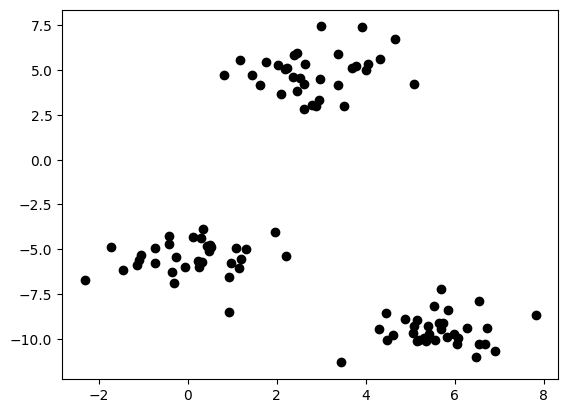

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, _ = make_blobs(random_state=10)
plt.scatter(X[:, 0], X[:, 1],color='black')

In [ ]:
kmeans = KMeans(init='random',n_clusters=3)
kmeans.fit(X)
y_pred = kmeans.predict(X)

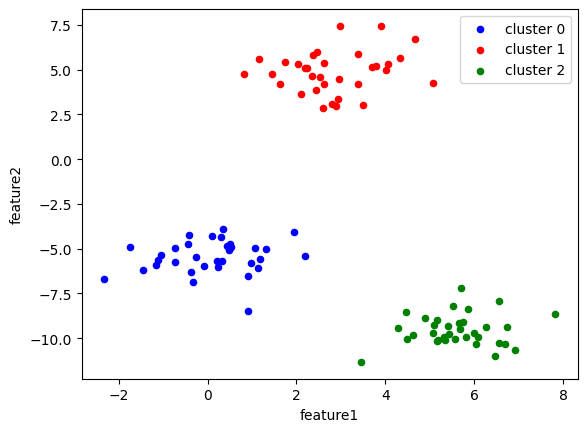

In [ ]:
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis = 1)
merge_data.columns = ['feature1', 'feature2', 'cluster']

ax = None
colors = ['blue', 'red', 'green']
for i, data in merge_data.groupby('cluster'):
    ax = data.plot.scatter(x = 'feature1', y = 'feature2', color = colors[i], label = 'cluster {}'.format(i), ax = ax)

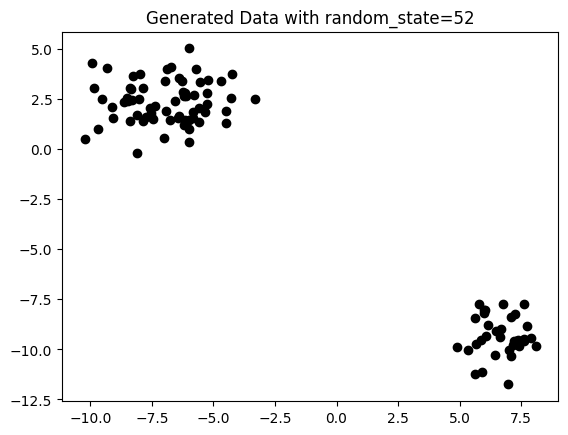

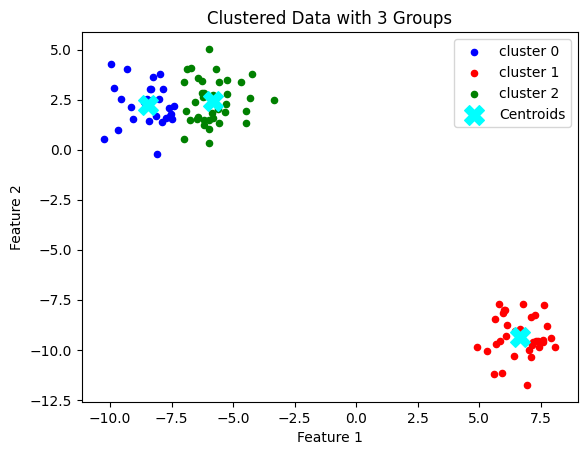

In [ ]:
import pandas as pd

X_new, _ = make_blobs(random_state=52)
plt.scatter(X_new[:, 0], X_new[:, 1], color='black')
plt.title('Generated Data with random_state=52')
plt.show()

kmeans_new = KMeans(n_clusters=3, random_state=52, n_init='auto')
kmeans_new.fit(X_new)
y_pred_new = kmeans_new.predict(X_new)

merge_data_new = pd.concat([pd.DataFrame(X_new[:,0]), pd.DataFrame(X_new[:,1]), pd.DataFrame(y_pred_new)], axis = 1)
merge_data_new.columns = ['feature1', 'feature2', 'cluster']

ax_new = None
colors_new = ['blue', 'red', 'green', 'purple', 'orange', 'brown'] # Add more colors if more clusters are used
for i, data in merge_data_new.groupby('cluster'):
    ax_new = data.plot.scatter(x = 'feature1', y = 'feature2', color = colors_new[i], label = 'cluster {}'.format(i), ax = ax_new)

# Also plot the cluster centers
plt.scatter(kmeans_new.cluster_centers_[:, 0], kmeans_new.cluster_centers_[:, 1], s=200, c='cyan', marker='X', label='Centroids')

plt.title('Clustered Data with 3 Groups')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

相関係数0.889:


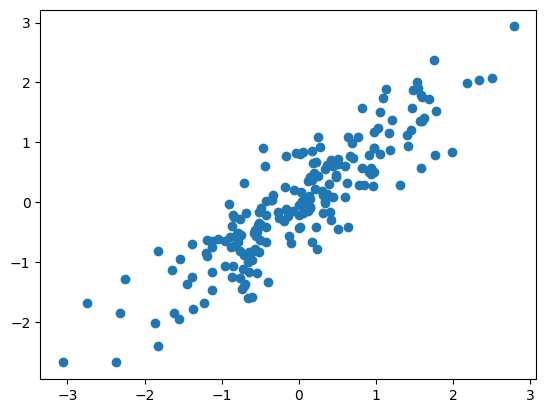

In [ ]:
from sklearn.preprocessing import StandardScaler
import scipy as sp

sample = np.random.RandomState(1)

X = np.dot(sample.rand(2, 2), sample.randn(2, 200)).T

sc = StandardScaler()
X_std = sc.fit_transform(X)

print('相関係数{:.3f}:'.format(sp.stats.pearsonr(X_std[:, 0], X_std[:, 1])[0]))
plt.scatter(X_std[:, 0], X_std[:, 1])

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_std)

PCA(n_components=2)

In [ ]:
print(pca.components_)

[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [ ]:
print('各主成分の分数:{}'.format(pca.explained_variance_))

各主成分の分数:[1.89888438 0.11116588]


In [ ]:
print('各主成分の分数:{}'.format(pca.explained_variance_ratio_))

各主成分の分数:[0.94469498 0.05530502]


(np.float64(-3.3534087054527717),
 np.float64(3.079070151762556),
 np.float64(-2.9610077757452697),
 np.float64(3.2159825436132246))

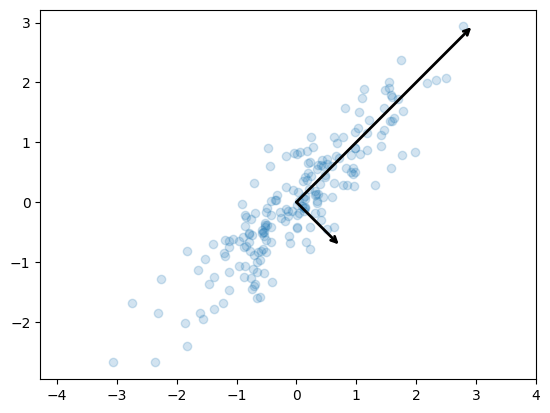

In [ ]:
arrowprops = dict(arrowstyle='->',
                  linewidth=2,
                  shrinkA=0, shrinkB=0)

def draw_vector(v0, v1):
    plt.gca().annotate('', v1, v0, arrowprops=arrowprops)

plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)

plt.axis('equal')

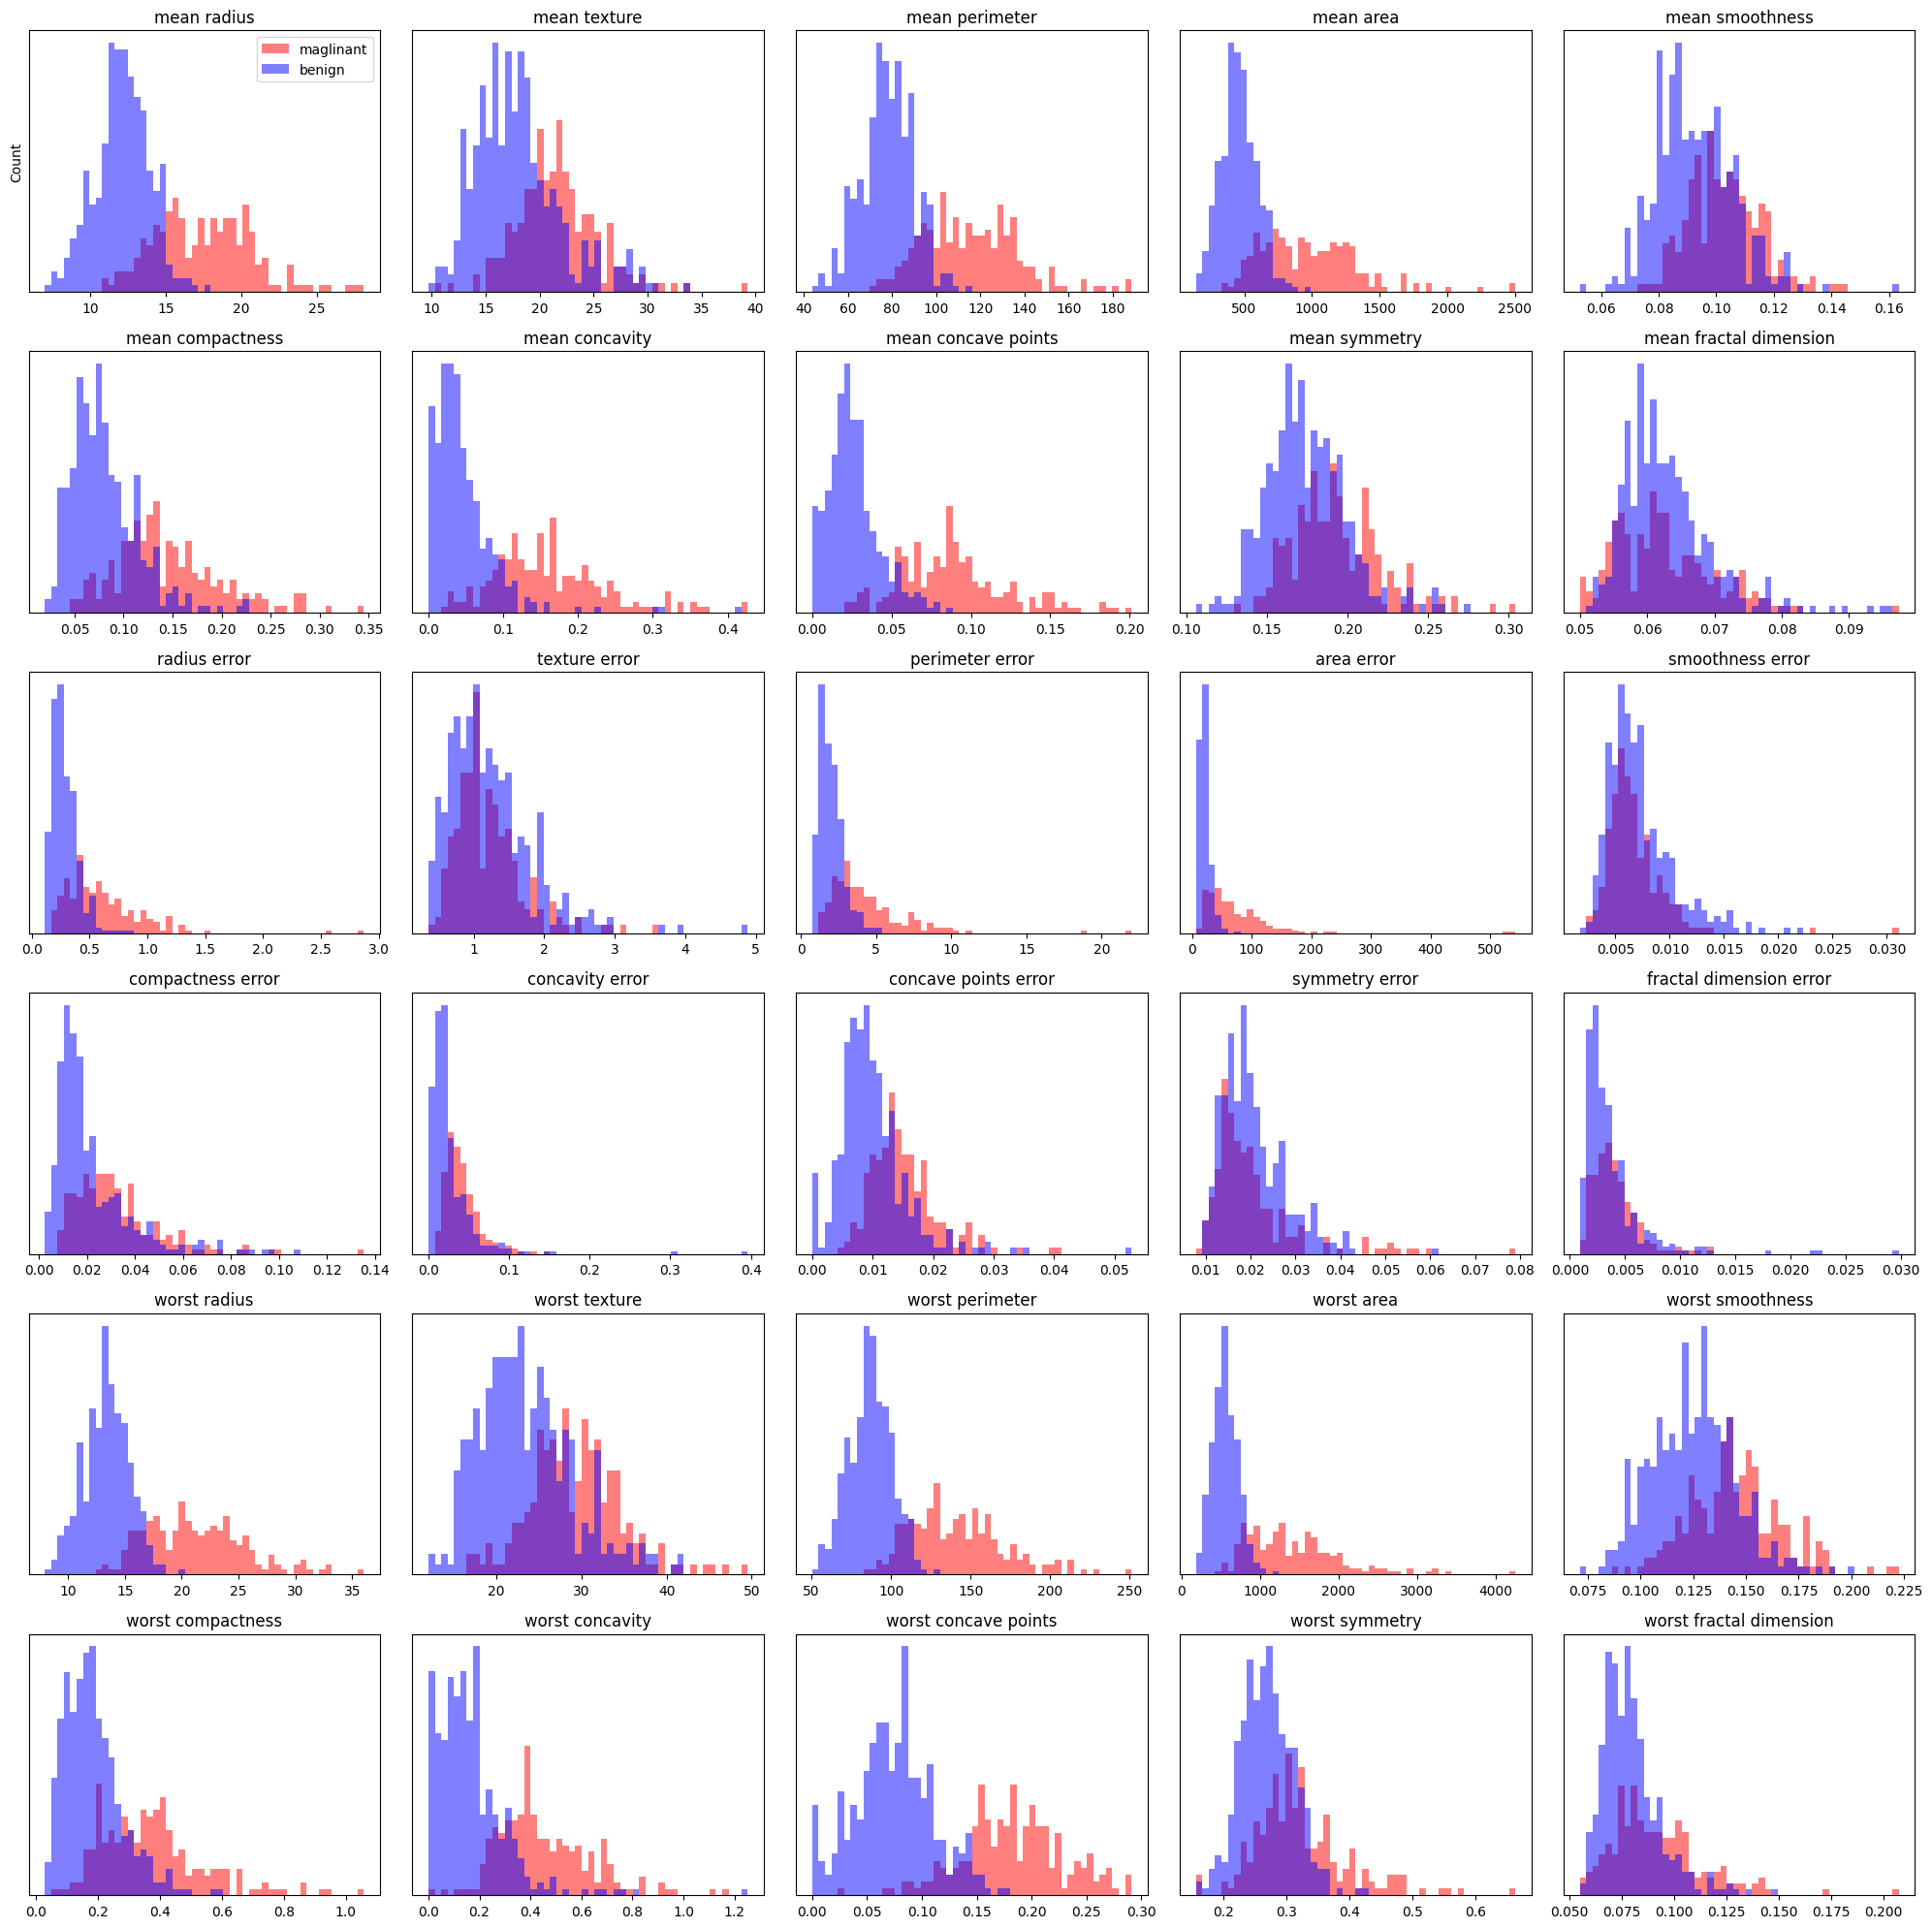

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

fig, axes = plt.subplots(6, 5, figsize=(20, 20))
ax = axes.ravel()

for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color='red', alpha=0.5, label='malignant')
    ax[i].hist(benign[:, i], bins=bins, color='blue', alpha=0.5, label='benign')
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_ylabel('Count')
ax[0].legend(['maglinant', 'benign'], loc='best')
fig.tight_layout()

In [ ]:
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)

pca = PCA(n_components=2)
pca.fit(X_std)

X_pca = pca.transform(X_std)

print('X_pca_shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))

X_pca_shape:(569, 2)
Explained variance ratio:[0.44272026 0.18971182]


In [ ]:
import pandas as pd

X_pca = pd.DataFrame(X_pca, columns = ['pc1', 'pc2'])

X_pca = pd.concat([X_pca, pd.DataFrame(cancer.target, columns = ['target'])], axis = 1)

pca_malignant = X_pca[X_pca['target'] == 0]
pca_benign = X_pca[X_pca['target'] == 1]

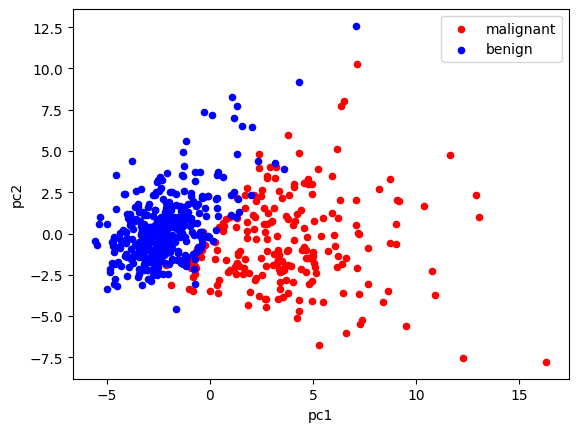

In [ ]:
ax = pca_malignant.plot.scatter(x = 'pc1', y = 'pc2', color = 'red', label = 'malignant');

pca_benign.plot.scatter(x = 'pc1', y = 'pc2', color = 'blue', label = 'benign', ax = ax);

各主成分の寄与率: [0.72962445 0.22850762]
累積寄与率: 0.958


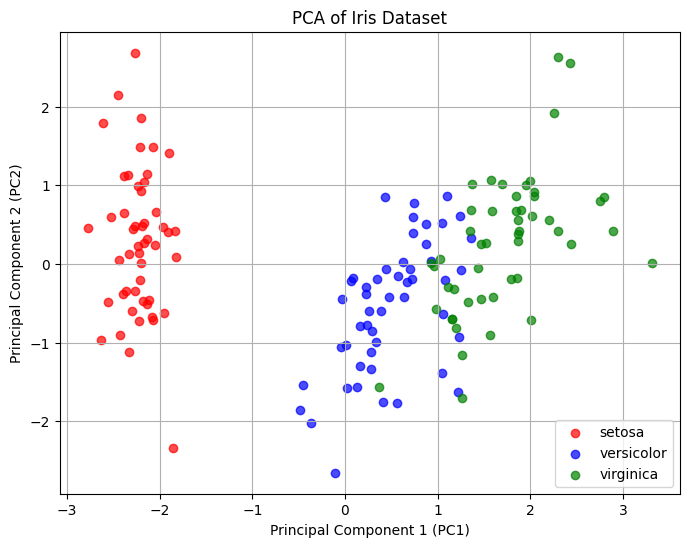

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print(f"各主成分の寄与率: {pca.explained_variance_ratio_}")
print(f"累積寄与率: {sum(pca.explained_variance_ratio_):.3f}")

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["target"] = y

colors = ["red", "blue", "green"]
plt.figure(figsize=(8, 6))

for i, color in enumerate(colors):
    subset = df_pca[df_pca["target"] == i]
    plt.scatter(
        subset["PC1"], subset["PC2"], color=color, label=target_names[i], alpha=0.7
    )

plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

#考察
アヤメの元データは4つの特徴量（がく片の長さ・幅、花弁の長さ・幅）を持つ「4次元」のデータだが，これを2次元（PC1とPC2）に圧縮したにもかかわらず，品種ごとのクラスタ構造が綺麗に可視化できるので，PCAによってデータの持つ重要な情報が損なわれずに抽出できている結果が得られたといえる。